# Microparticles Saint John — Pipeline Demo

This notebook demonstrates the complete data pipeline for the *Integration and data sharing to examine the fate and transport of microplastics in the Wolastoq/Saint John River watershed* project.

It covers:
1. Loading data from local CSV files
2. Joining tables and filtering to the SJ River watershed
3. Calculating normalized MP concentrations
4. Nonparametric statistical tests (Kruskal-Wallis + Dunn post-hoc)
5. Generalized Linear Models (Negative Binomial, AIC selection)
6. Publication-quality figures
7. FTIR polymer composition summaries

---
**Data source:** Local CSV files exported from AWS DynamoDB (`us-east-1`)  
**Tables:** Site, Animal, Sediment, Water, FTIR  
**Place CSV files in the `data/` directory before running.**

## 0. Configuration

In [ ]:
import os

CSV_PATHS = {
    "sites":    "data/Site.csv",
    "animal":   "data/Animal.csv",
    "sediment": "data/Sediment.csv",
    "water":    "data/Water.csv",
    "ftir":     "data/FTIR.csv",
}

os.makedirs("outputs", exist_ok=True)
print("Configuration set.")

Configuration set.


## 1. Imports

In [10]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
from scipy import stats
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import scikit_posthocs as sp
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", "{:.4f}".format)
print("Imports complete.")

Imports complete.


## 2. Load Data

In [11]:
print("Loading CSV files...")
sites    = pd.read_csv(CSV_PATHS["sites"])
animal   = pd.read_csv(CSV_PATHS["animal"])
sediment = pd.read_csv(CSV_PATHS["sediment"])
water    = pd.read_csv(CSV_PATHS["water"])
ftir     = pd.read_csv(CSV_PATHS["ftir"])

print(f"Rows loaded:")
print(f"  Site:     {len(sites)}")
print(f"  Animal:   {len(animal)}")
print(f"  Sediment: {len(sediment)}")
print(f"  Water:    {len(water)}")
print(f"  FTIR:     {len(ftir)}")

Loading CSV files...
Rows loaded:
  Site:     426
  Animal:   803
  Sediment: 779
  Water:    224
  FTIR:     3149


In [12]:
# Preview Site table
sites.head(3)

,collection_organization,primarycontact,year,waterbody,waterbodytype,site,siteid,latitude,longitude,substrate,benthicpelagic,tidaldepth,samplestaken,sampletypes
0,Mount Allison University,Josh Kurek,2020,Saint John River,Freshwater,Gf Bkgr,2020Gf BkgrSediment,47.0561,-67.7558,Mud/silt/rocky,Benthic,NaN,1,Sediment
1,Mount Allison University,Josh Kurek,2020,Saint John River,Freshwater,Gf Bkgr,2020Gf BkgrWater,47.0561,-67.7558,Mud/silt/rocky,Benthic,NaN,1,Water
2,Mount Allison University,Josh Kurek,2020,Saint John River,Freshwater,Gf-Drum US,2020Gf-Drum USAnimal,47.0409,-67.7399,Sediment/rocky,Benthic,NaN,5,Animal


In [13]:
# Preview FTIR table — individual particle records
ftir.head(3)

,collection_organization,primarycontact,date,sampleid,id,mp_id,common_plastic,common_plastic_certainty,ftir_primary,ftir_primary_certainty,ftir_secondary,ftir_tertiary,ftir_quarternary,ftir_quinary,cellulosic_peak,ftir_size_microns,ftir_scope_mag,colour,other_colour,structure,plastic_size,filename,Unnamed: 22
0,Mount Alison University,Krista Beardy,2/28/2024,Arthurette_Water-41_6 OF 10,2020Arthurette TobiqueWaterArthurette,2020Arthurette TobiqueWaterArthurette_6,Y,NaN,Matches to ethylene/ethyl acrylate co polymers,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Grey,NaN,Film/Fragment,NaN,DC_Arthurette_WATER-41_6OF10_GREYFILM/FRAGMENT,NaN
1,Passmaquoddy Recognition Group Inc,Bronte Thomas,NaN,2020BP_t1_10,2020Black Point 1Animal2020BP_t1_10,2020Black Point 1Animal2020BP_t1_10_1,N,Known,Inorganic,N,Potassium carbonate,NaN,NaN,NaN,NaN,NaN,NaN,Black,NaN,Fiber,NaN,NaN,NaN
2,Passmaquoddy Recognition Group Inc,Bronte Thomas,NaN,2020BP_t1_10,2020Black Point 1Animal2020BP_t1_10,2020Black Point 1Animal2020BP_t1_10_2,N,Known,Cellulose,Y,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Purple,NaN,Fiber,1.4000,NaN,NaN


## 3. Type Coercion

In [14]:
NUM_COLS = ["totalmp", "fibre", "fragment", "sphere", "film", "ftir_numbersent"]

for df in [animal, sediment, water]:
    for col in NUM_COLS:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")

for col in ["sampleweight", "animallength", "number_animal"]:
    if col in animal.columns:
        animal[col] = pd.to_numeric(animal[col], errors="coerce")

if "sampleweight_wwt" in sediment.columns:
    sediment["sampleweight_wwt"] = pd.to_numeric(sediment["sampleweight_wwt"], errors="coerce")

if "samplevolume" in water.columns:
    water["samplevolume"] = pd.to_numeric(water["samplevolume"], errors="coerce")

for col in ["latitude", "longitude"]:
    if col in sites.columns:
        sites[col] = pd.to_numeric(sites[col], errors="coerce")

if "ftir_size_microns" in ftir.columns:
    ftir["ftir_size_microns"] = pd.to_numeric(ftir["ftir_size_microns"], errors="coerce")

print("Type coercion complete.")

Type coercion complete.


## 4. Filter Sites to SJ River Watershed

In [15]:
WATERSHED_WATERBODIES = [
    "Saint John River", "Tobique River", "Nashwaak River",
    "Oromocto River",   "Kennebecasis River", "Saint John Harbour",
]

sites["siteid"] = sites["siteid"].astype(str)
sites_sj = sites[sites["waterbody"].isin(WATERSHED_WATERBODIES)].copy()

sites_sj_anim = sites_sj[sites_sj["sampletypes"] == "Animal"].copy()
sites_sj_sed  = sites_sj[sites_sj["sampletypes"] == "Sediment"].copy()
sites_sj_wat  = sites_sj[sites_sj["sampletypes"] == "Water"].copy()

print(f"Watershed sites — Animal: {len(sites_sj_anim)}, "
      f"Sediment: {len(sites_sj_sed)}, Water: {len(sites_sj_wat)}")
print(f"\nSamples per waterbody:")
print(sites_sj["waterbody"].value_counts().to_string())

Watershed sites — Animal: 60, Sediment: 112, Water: 102

Samples per waterbody:
waterbody
Saint John River      98
Saint John Harbour    52
Tobique River         48
Kennebecasis River    32
Nashwaak River        29
Oromocto River        15


## 5. Merge Sample Tables with Site Metadata

In [16]:
for df in [animal, sediment, water]:
    df["siteid"] = df["siteid"].astype(str)

animal_site   = animal.merge(sites_sj_anim,  on="siteid", suffixes=("_x", "_y"))
sediment_site = sediment.merge(sites_sj_sed, on="siteid", suffixes=("_x", "_y"))
water_site    = water.merge(sites_sj_wat,    on="siteid", suffixes=("_x", "_y"))

# Drop partner-specific sub-columns not in the DynamoDB schema
DROP_PATTERNS = ["jk_", "ca_", "acap_", "prg_", "huntsman_",
                 "pelletnurdle", "foam", "microfibre", "threads",
                 "microbead", "X."]

def drop_extra_cols(df):
    drop = [c for c in df.columns
            if any(c.startswith(p) for p in DROP_PATTERNS)]
    return df.drop(columns=drop, errors="ignore")

animal_site   = drop_extra_cols(animal_site)
sediment_site = drop_extra_cols(sediment_site)
water_site    = drop_extra_cols(water_site)

print(f"Merged rows — animal: {len(animal_site)}, "
      f"sediment: {len(sediment_site)}, water: {len(water_site)}")
animal_site[["siteid", "waterbody", "species_common", "totalmp", "sampleweight"]].head(5)

Merged rows — animal: 558, sediment: 184, water: 128


,siteid,waterbody,species_common,totalmp,sampleweight
0,20191Animal,Saint John Harbour,Acartia longiremis,1.0000,NaN
1,20191Animal,Saint John Harbour,Acartia longiremis,2.0000,NaN
2,20191Animal,Saint John Harbour,Acartia longiremis,5.0000,NaN
3,20191Animal,Saint John Harbour,Acartia longiremis,11.0000,NaN
4,20192Animal,Saint John Harbour,Acartia longiremis,2.0000,NaN


## 6. Bivalve Subset

In [17]:
BIVALVE_SPECIES = [
    "Balthic clam", "Blue Mussel", "Eastern elliptio",
    "Eastern lampmussel", "Freshwater pearl mussel",
    "Macoma clam", "Ribbed Mussel", "Soft Shelled Clam", "Soft-shell clam",
]

bivalve_site     = animal_site[animal_site["species_common"].isin(BIVALVE_SPECIES)].copy()
bivalve_sjh_site = bivalve_site[bivalve_site["waterbody"] == "Saint John Harbour"].copy()

print(f"Bivalves (all watershed): {len(bivalve_site)}")
print(f"Bivalves (SJH only):      {len(bivalve_sjh_site)}")
print(f"\nSpecies counts:")
print(bivalve_site["species_common"].value_counts().to_string())

Bivalves (all watershed): 218
Bivalves (SJH only):      43

Species counts:
species_common
Freshwater pearl mussel    109
Eastern elliptio            56
Blue Mussel                 30
Eastern lampmussel          10
Soft Shelled Clam            9
Macoma clam                  4


## 7. Normalized MP Concentrations

- **Animal / bivalve:** MPs per gram tissue (`count / sampleweight`)
- **Sediment:** MPs per gram dry weight (`count / sampleweight_wwt`)
- **Water:** MPs per mL (`count / samplevolume`)

In [18]:
def add_concentrations(df, denominator):
    for col in ["totalmp", "fibre", "fragment", "sphere", "film"]:
        if col in df.columns and denominator in df.columns:
            df[f"{col}_g"] = df[col] / df[denominator]
    return df

animal_site      = add_concentrations(animal_site,      "sampleweight")
bivalve_site     = add_concentrations(bivalve_site,     "sampleweight")
bivalve_sjh_site = add_concentrations(bivalve_sjh_site, "sampleweight")
sediment_site    = add_concentrations(sediment_site,    "sampleweight_wwt")
water_site       = add_concentrations(water_site,       "samplevolume")

print("Concentration columns added.")
bivalve_site[["siteid", "waterbody", "species_common",
              "totalmp", "sampleweight", "totalmp_g"]].head(5)

Concentration columns added.


,siteid,waterbody,species_common,totalmp,sampleweight,totalmp_g
96,2020Digby Ferry CA Animal,Saint John Harbour,Blue Mussel,0.0000,3.6300,0.0000
97,2020Digby Ferry CA Animal,Saint John Harbour,Blue Mussel,4.0000,3.3700,1.1869
98,2020Digby Ferry CA Animal,Saint John Harbour,Blue Mussel,7.0000,3.9500,1.7722
99,2020Digby Ferry CA Animal,Saint John Harbour,Blue Mussel,6.0000,7.5500,0.7947
100,2020Digby Ferry CA Animal,Saint John Harbour,Blue Mussel,3.0000,7.1700,0.4184


## 8. Site-Level Averages per Year

In [19]:
CONC_COLS = ["totalmp_g", "fibre_g", "fragment_g", "sphere_g", "film_g"]

def site_averages(df, year_col="year_x"):
    conc_present = [c for c in CONC_COLS if c in df.columns]
    group_cols   = ["siteid"] + ([year_col] if year_col in df.columns else [])
    averages = df.groupby(group_cols, as_index=False).agg(
        **{f"avg_{col}": (col, "mean") for col in conc_present}
    )
    distinct = df.drop_duplicates(subset=["siteid"], keep="first")
    return averages.merge(distinct, on="siteid", suffixes=("_avg", ""))

animal_site_avg   = site_averages(animal_site)
bivalve_site_avg  = site_averages(bivalve_site)
sediment_site_avg = site_averages(sediment_site)
water_site_avg    = site_averages(water_site)

print(f"Site-year averages — animal: {len(animal_site_avg)}, "
      f"bivalve: {len(bivalve_site_avg)}, "
      f"sediment: {len(sediment_site_avg)}, water: {len(water_site_avg)}")
bivalve_site_avg[["siteid", "waterbody", "avg_totalmp_g", "avg_fibre_g"]].head(5)

Site-year averages — animal: 58, bivalve: 44, sediment: 112, water: 102


,siteid,waterbody,avg_totalmp_g,avg_fibre_g
0,2018Courtney BayAnimal,Saint John Harbour,3.2549,2.4758
1,2018Inner HbrAnimal,Saint John Harbour,1.3431,0.8174
2,2018LornevilleAnimal,Saint John Harbour,0.6089,0.4087
3,2019APO DSAnimal,Kennebecasis River,0.0363,0.0363
4,2019APO USAnimal,Kennebecasis River,0.0732,0.0721


## 9. Figures

### Fig 1 — Site Map

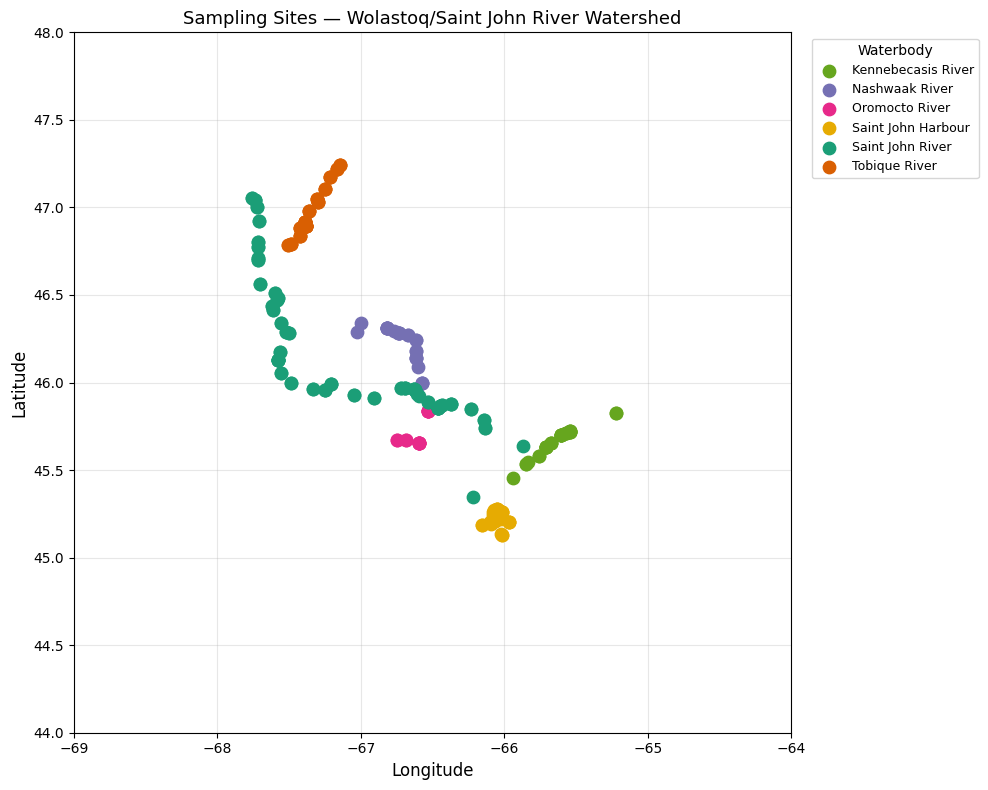

In [20]:
PALETTE    = sns.color_palette("Dark2", n_colors=len(WATERSHED_WATERBODIES))
wb_colors  = dict(zip(WATERSHED_WATERBODIES, PALETTE))

fig, ax = plt.subplots(figsize=(10, 8))

for wb, group in sites_sj.groupby("waterbody"):
    ax.scatter(
        group["longitude"], group["latitude"],
        color=wb_colors.get(wb, "grey"),
        label=wb, s=80, zorder=5
    )

ax.set_xlim(-69, -64)
ax.set_ylim(44, 48)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.set_title("Sampling Sites — Wolastoq/Saint John River Watershed", fontsize=13)
ax.legend(title="Waterbody", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("outputs/fig1_site_map.png", dpi=150, bbox_inches="tight")
plt.show()

### Fig 2 — Bivalve MP Concentration by Waterbody

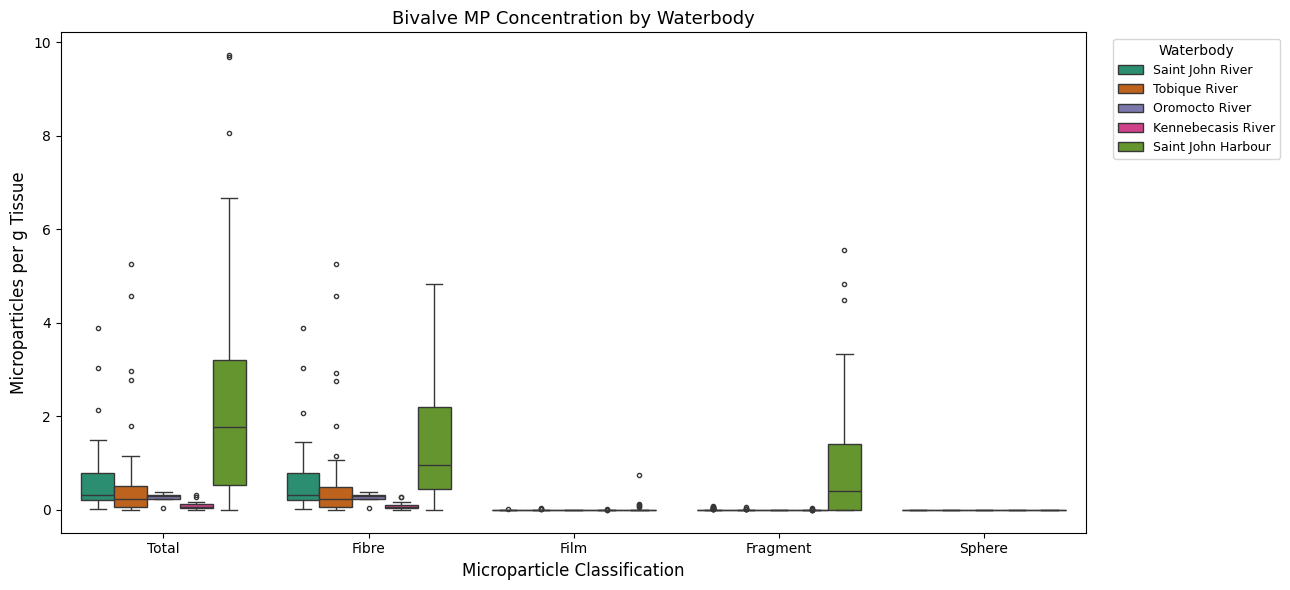

In [21]:
MP_LABELS  = {"totalmp_g": "Total", "fibre_g": "Fibre",
              "film_g": "Film", "fragment_g": "Fragment", "sphere_g": "Sphere"}
MP_ORDER   = ["Total", "Fibre", "Film", "Fragment", "Sphere"]

bivalve_long = bivalve_site.melt(
    id_vars=[c for c in bivalve_site.columns if c not in CONC_COLS],
    value_vars=[c for c in CONC_COLS if c in bivalve_site.columns],
    var_name="mp_type", value_name="value"
)
bivalve_long["mp_type"] = bivalve_long["mp_type"].map(MP_LABELS)
bivalve_long = bivalve_long.dropna(subset=["value", "waterbody"])
wbs_present  = [w for w in WATERSHED_WATERBODIES if w in bivalve_long["waterbody"].unique()]

fig, ax = plt.subplots(figsize=(13, 6))
sns.boxplot(
    data=bivalve_long, x="mp_type", y="value", hue="waterbody",
    order=MP_ORDER, hue_order=wbs_present,
    palette="Dark2", ax=ax, fliersize=3
)
ax.set_xlabel("Microparticle Classification", fontsize=12)
ax.set_ylabel("Microparticles per g Tissue", fontsize=12)
ax.set_title("Bivalve MP Concentration by Waterbody", fontsize=13)
ax.legend(title="Waterbody", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.savefig("outputs/fig2_bivalve_boxplot.png", dpi=150, bbox_inches="tight")
plt.show()

### Fig 3 — Sediment and Water Concentrations by Waterbody

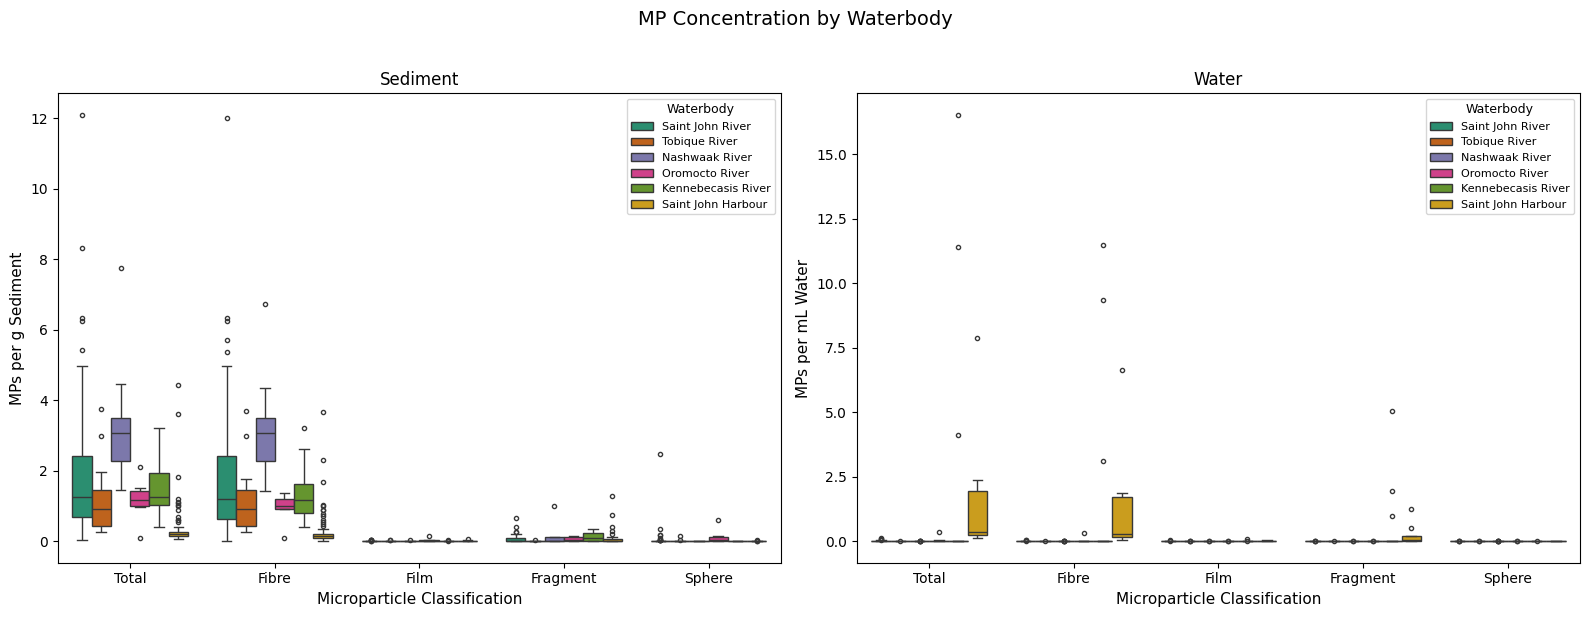

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, df, ylabel, title in [
    (axes[0], sediment_site, "MPs per g Sediment", "Sediment"),
    (axes[1], water_site,    "MPs per mL Water",   "Water"),
]:
    long = df.melt(
        id_vars=[c for c in df.columns if c not in CONC_COLS],
        value_vars=[c for c in CONC_COLS if c in df.columns],
        var_name="mp_type", value_name="value"
    )
    long["mp_type"] = long["mp_type"].map(MP_LABELS)
    long = long.dropna(subset=["value", "waterbody"])
    wbs  = [w for w in WATERSHED_WATERBODIES if w in long["waterbody"].unique()]

    sns.boxplot(
        data=long, x="mp_type", y="value", hue="waterbody",
        order=MP_ORDER, hue_order=wbs,
        palette="Dark2", ax=ax, fliersize=3
    )
    ax.set_xlabel("Microparticle Classification", fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title, fontsize=12)
    ax.legend(title="Waterbody", fontsize=8, title_fontsize=9)

plt.suptitle("MP Concentration by Waterbody", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("outputs/fig3_sediment_water_boxplots.png", dpi=150, bbox_inches="tight")
plt.show()

## 10. FTIR Summaries

Aggregated from individual particle records. The `id` column encodes the sample matrix (`Animal`, `Water`, or `Sediment`) in its string structure, which we use to infer matrix when needed.

In [23]:
# Infer sample matrix from the id string (e.g. '2022_HarbourNorth_Animal_S01_03')
def infer_matrix(id_str):
    id_str = str(id_str)
    if "Animal" in id_str:   return "Bivalve"
    if "Water" in id_str:    return "Water"
    if "Sediment" in id_str: return "Sediment"
    return "Unknown"

ftir["Matrix"] = ftir["id"].apply(infer_matrix)

# Plastic vs non-plastic label
ftir["Type"] = ftir["common_plastic"].map({"Y": "Artificial", "N": "Natural"})

print("Matrix breakdown:")
print(ftir["Matrix"].value_counts().to_string())
print("\nPlastic confirmation:")
print(ftir["Type"].value_counts().to_string())

Matrix breakdown:
Matrix
Bivalve    2057
Water      1018
Unknown      74

Plastic confirmation:
Type
Natural       1552
Artificial     975


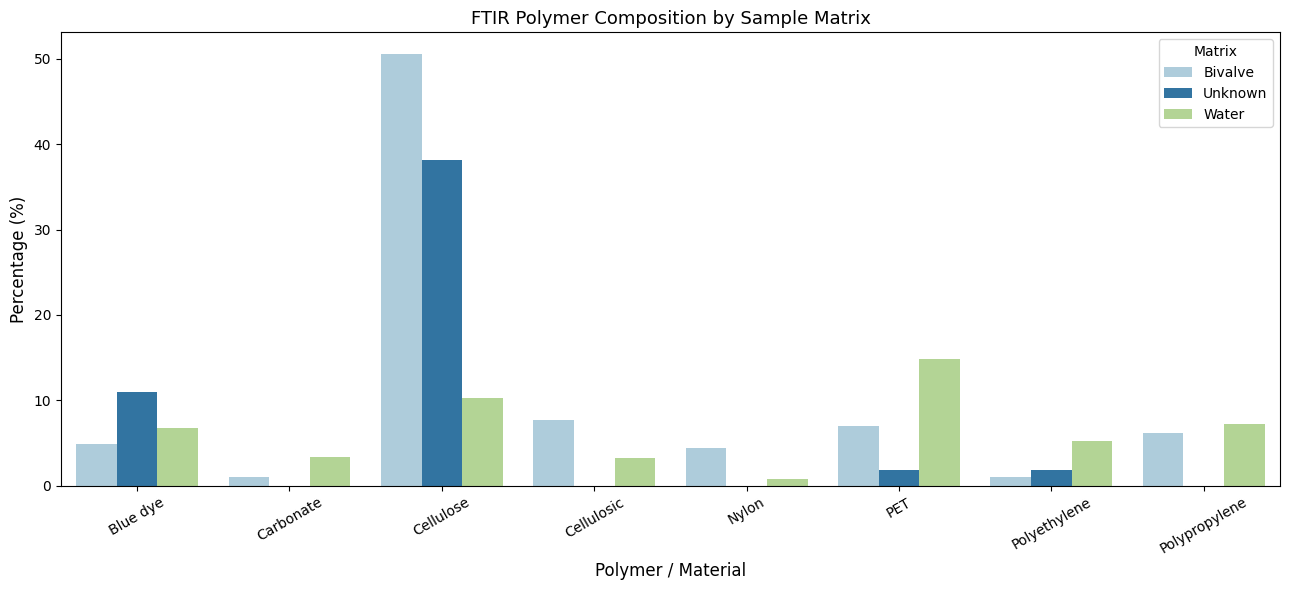

In [24]:
# Fig 4 — Polymer composition by matrix (bar chart)
ftir_compound = (
    ftir.groupby(["Matrix", "ftir_primary"])
    .size()
    .reset_index(name="Count")
)
ftir_compound["Percent"] = ftir_compound.groupby("Matrix")["Count"].transform(
    lambda x: x / x.sum() * 100
)

# Keep top compounds for readability
top_compounds = (
    ftir_compound.groupby("ftir_primary")["Count"]
    .sum()
    .nlargest(8)
    .index
)
ftir_top = ftir_compound[ftir_compound["ftir_primary"].isin(top_compounds)]

fig, ax = plt.subplots(figsize=(13, 6))
sns.barplot(
    data=ftir_top, x="ftir_primary", y="Percent", hue="Matrix",
    palette="Paired", ax=ax
)
ax.set_xlabel("Polymer / Material", fontsize=12)
ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_title("FTIR Polymer Composition by Sample Matrix", fontsize=13)
ax.tick_params(axis="x", rotation=30)
ax.legend(title="Matrix")
plt.tight_layout()
plt.savefig("outputs/fig4_ftir_polymer.png", dpi=150, bbox_inches="tight")
plt.show()

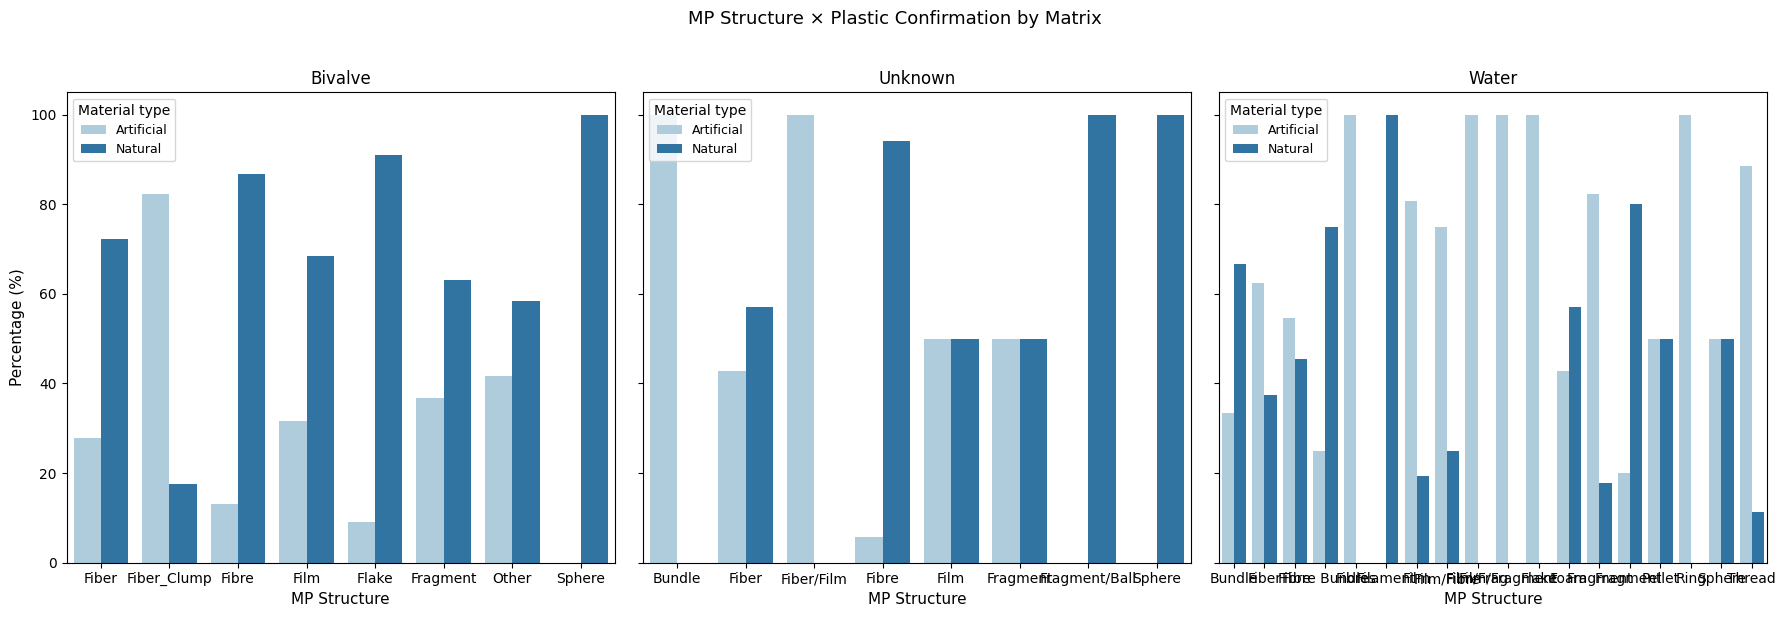

In [25]:
# Fig 5 — MP structure × plastic confirmation by matrix
ftir_shape = (
    ftir.dropna(subset=["structure", "Type", "Matrix"])
    .groupby(["Matrix", "structure", "Type"])
    .size()
    .reset_index(name="Count")
)
ftir_shape["Percent"] = ftir_shape.groupby(["Matrix", "structure"])["Count"].transform(
    lambda x: x / x.sum() * 100
)

matrices = ftir_shape["Matrix"].unique()
fig, axes = plt.subplots(1, len(matrices), figsize=(6 * len(matrices), 6), sharey=True)
if len(matrices) == 1:
    axes = [axes]

for ax, matrix in zip(axes, matrices):
    sub = ftir_shape[ftir_shape["Matrix"] == matrix]
    sns.barplot(
        data=sub, x="structure", y="Percent", hue="Type",
        palette="Paired", ax=ax
    )
    ax.set_title(matrix, fontsize=12)
    ax.set_xlabel("MP Structure", fontsize=11)
    ax.set_ylabel("Percentage (%)" if ax == axes[0] else "", fontsize=11)
    ax.legend(title="Material type", fontsize=9)

plt.suptitle("MP Structure × Plastic Confirmation by Matrix", fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig("outputs/fig5_ftir_shape_confirmation.png", dpi=150, bbox_inches="tight")
plt.show()

## 11. Nonparametric Tests — Kruskal-Wallis + Dunn Post-hoc

In [26]:
def run_kruskal_dunn(df, response, group_var, label):
    sub    = df[[response, group_var]].dropna()
    groups = [grp[response].values for _, grp in sub.groupby(group_var)]

    if len(groups) < 2:
        print(f"  {label}: fewer than 2 groups, skipped.")
        return

    stat, p  = stats.kruskal(*groups)
    sig_flag = "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else "ns"))
    print(f"\n{'='*60}")
    print(f"{label}")
    print(f"  Kruskal-Wallis  H = {stat:.3f},  p = {p:.4f}  {sig_flag}")

    if p < 0.05:
        dunn = sp.posthoc_dunn(sub, val_col=response, group_col=group_var,
                               p_adjust="bonferroni")
        sig  = dunn < 0.05
        pairs = [(g1, g2) for g1 in dunn.index for g2 in dunn.columns
                 if g1 < g2 and sig.loc[g1, g2]]
        if pairs:
            print("  Significant pairwise differences (Dunn/Bonferroni):")
            for g1, g2 in pairs:
                print(f"    {g1}  vs  {g2}:  p = {dunn.loc[g1, g2]:.4f} *")
        else:
            print("  No significant pairwise differences after Bonferroni correction.")

run_kruskal_dunn(bivalve_site,     "totalmp_g", "waterbody",     "Bivalves (all watershed) ~ waterbody")
run_kruskal_dunn(bivalve_sjh_site, "totalmp_g", "species_common","Bivalves (Saint John Harbour) ~ species")
run_kruskal_dunn(sediment_site,    "totalmp_g", "waterbody",     "Sediment ~ waterbody")
run_kruskal_dunn(water_site,       "totalmp_g", "waterbody",     "Water ~ waterbody")


Bivalves (all watershed) ~ waterbody
  Kruskal-Wallis  H = 90.868,  p = 0.0000  ***
  Significant pairwise differences (Dunn/Bonferroni):
    Kennebecasis River  vs  Saint John Harbour:  p = 0.0000 *
    Kennebecasis River  vs  Saint John River:  p = 0.0000 *
    Kennebecasis River  vs  Tobique River:  p = 0.0005 *
    Saint John Harbour  vs  Saint John River:  p = 0.0001 *
    Saint John Harbour  vs  Tobique River:  p = 0.0000 *

Bivalves (Saint John Harbour) ~ species
  Kruskal-Wallis  H = 7.013,  p = 0.0300  *
  No significant pairwise differences after Bonferroni correction.

Sediment ~ waterbody
  Kruskal-Wallis  H = 87.283,  p = 0.0000  ***
  Significant pairwise differences (Dunn/Bonferroni):
    Kennebecasis River  vs  Saint John Harbour:  p = 0.0000 *
    Nashwaak River  vs  Saint John Harbour:  p = 0.0000 *
    Saint John Harbour  vs  Saint John River:  p = 0.0000 *
    Saint John Harbour  vs  Tobique River:  p = 0.0011 *

Water ~ waterbody
  Kruskal-Wallis  H = 63.307,  p =

## 12. GLMs — Negative Binomial (AIC Selection)

In [27]:
def fit_and_compare(df, response, predictor, label):
    sub = df[[response, predictor]].dropna().copy()
    sub[predictor] = sub[predictor].astype(str)
    formula = f"{response} ~ C({predictor})"

    print(f"\n{'='*60}")
    print(f"{label}")

    models = {}
    for name, family in [
        ("Gaussian",         sm.families.Gaussian()),
        ("NegativeBinomial", sm.families.NegativeBinomial()),
    ]:
        try:
            m = smf.glm(formula, data=sub, family=family).fit(disp=0)
            models[name] = m
            print(f"  {name:<22} AIC = {m.aic:.2f}")
        except Exception as e:
            print(f"  {name:<22} failed: {e}")

    # Summarize best model
    best_name = "NegativeBinomial" if "NegativeBinomial" in models else "Gaussian"
    best = models.get(best_name)
    if best:
        coef_df = pd.DataFrame({
            "coef":   best.params.round(4),
            "pvalue": best.pvalues.round(4),
            "sig":    best.pvalues.apply(
                lambda p: "***" if p < 0.001 else ("**" if p < 0.01 else ("*" if p < 0.05 else ""))
            )
        })
        print(f"\n  Best model ({best_name}) coefficients:")
        print(coef_df.to_string())

    return models

fit_and_compare(bivalve_site,     "totalmp_g", "waterbody",     "Bivalves (all) ~ waterbody")
fit_and_compare(bivalve_sjh_site, "totalmp_g", "species_common","Bivalves (SJH) ~ species")
fit_and_compare(sediment_site,    "totalmp_g", "waterbody",     "Sediment ~ waterbody")
fit_and_compare(water_site,       "totalmp_g", "waterbody",     "Water ~ waterbody")


Bivalves (all) ~ waterbody
  Gaussian               AIC = 731.52
  NegativeBinomial       AIC = 480.37

  Best model (NegativeBinomial) coefficients:
                                      coef  pvalue  sig
Intercept                          -2.4797  0.0000  ***
C(waterbody)[T.Oromocto River]      1.1268  0.3225     
C(waterbody)[T.Saint John Harbour]  3.3889  0.0000  ***
C(waterbody)[T.Saint John River]    1.9279  0.0015   **
C(waterbody)[T.Tobique River]       1.8255  0.0025   **

Bivalves (SJH) ~ species
  Gaussian               AIC = 200.29
  NegativeBinomial       AIC = 180.57

  Best model (NegativeBinomial) coefficients:
                                          coef  pvalue  sig
Intercept                               1.0502  0.0000  ***
C(species_common)[T.Macoma clam]        0.1233  0.8399     
C(species_common)[T.Soft Shelled Clam] -1.1604  0.0284    *

Sediment ~ waterbody
  Gaussian               AIC = 631.91
  NegativeBinomial       AIC = 499.90

  Best model (NegativeBin

{'Gaussian': <statsmodels.genmod.generalized_linear_model.GLMResultsWrapper at 0x24ab0939480>,
 'NegativeBinomial': <statsmodels.genmod.generalized_linear_model.GLMResultsWrapper at 0x24ab0938af0>}

### Tukey Post-hoc — Bivalves by Waterbody

In [28]:
sub   = bivalve_site[["totalmp_g", "waterbody"]].dropna()
tukey = pairwise_tukeyhsd(endog=sub["totalmp_g"], groups=sub["waterbody"])

tukey_df = pd.DataFrame(
    data=tukey._results_table.data[1:],
    columns=tukey._results_table.data[0]
)
print("Significant pairwise differences — Bivalves ~ waterbody (Tukey HSD):")
tukey_df[tukey_df["reject"] == True]

Significant pairwise differences — Bivalves ~ waterbody (Tukey HSD):


,group1,group2,meandiff,p-adj,lower,upper,reject
1,Kennebecasis River,Saint John Harbour,2.3985,0.0000,1.6243,3.1726,True
4,Oromocto River,Saint John Harbour,2.2237,0.0028,0.5586,3.8888,True
7,Saint John Harbour,Saint John River,-1.9063,0.0000,-2.6105,-1.2022,True
8,Saint John Harbour,Tobique River,-1.9624,0.0000,-2.6452,-1.2796,True


## 13. Summary Table — Mean Concentrations by Waterbody × Matrix

In [29]:
summary_rows = []
for label, df, col, unit in [
    ("Bivalve",  bivalve_site,  "totalmp_g", "MPs/g tissue"),
    ("Sediment", sediment_site, "totalmp_g", "MPs/g dry wt"),
    ("Water",    water_site,    "totalmp_g", "MPs/mL"),
]:
    grp = (
        df[df["waterbody"].isin(WATERSHED_WATERBODIES)]
        .groupby("waterbody")[col]
        .agg(N="count", Mean="mean", Median="median", SD="std")
        .reset_index()
    )
    grp["Matrix"] = label
    grp["Unit"]   = unit
    summary_rows.append(grp)

summary = (
    pd.concat(summary_rows, ignore_index=True)
    [["Matrix", "waterbody", "N", "Mean", "Median", "SD", "Unit"]]
    .sort_values(["Matrix", "waterbody"])
    .round(4)
)
summary

,Matrix,waterbody,N,Mean,Median,SD,Unit
0,Bivalve,Kennebecasis River,40,0.0838,0.0698,0.0681,MPs/g tissue
1,Bivalve,Oromocto River,5,0.2585,0.3087,0.1330,MPs/g tissue
2,Bivalve,Saint John Harbour,43,2.4822,1.7722,2.4880,MPs/g tissue
3,Bivalve,Saint John River,60,0.5759,0.3276,0.6981,MPs/g tissue
4,Bivalve,Tobique River,70,0.5198,0.2262,0.9361,MPs/g tissue
5,Sediment,Kennebecasis River,18,1.4763,1.2590,0.7644,MPs/g dry wt
6,Sediment,Nashwaak River,9,3.2879,3.0664,1.9261,MPs/g dry wt
7,Sediment,Oromocto River,6,1.1717,1.1628,0.6657,MPs/g dry wt
8,Sediment,Saint John Harbour,74,0.4011,0.2000,0.6893,MPs/g dry wt
9,Sediment,Saint John River,51,2.0858,1.2558,2.3381,MPs/g dry wt


---
## Pipeline Summary

| Step | Description | Output |
|------|-------------|--------|
| 1 | Load from CSV | 5 raw DataFrames |
| 2 | Type coercion | Numeric MP counts, float coordinates |
| 3 | Watershed filter | Sites restricted to SJ River watershed |
| 4 | Merge | Sample tables joined to site metadata on `siteid` |
| 5 | Bivalve subset | Animal table filtered to bivalve species |
| 6 | Concentration normalization | MPs/g tissue, MPs/g dry wt, MPs/mL |
| 7 | Site averages | Mean concentration per site per year |
| 8 | Figures | Site map, boxplots, FTIR composition charts |
| 9 | Kruskal-Wallis + Dunn | Nonparametric group comparisons |
| 10 | NB GLMs | Family selection by AIC, Tukey post-hoc |
| 11 | Summary table | Mean concentrations by waterbody × matrix |

**Data:** CSV exports from AWS DynamoDB (`us-east-1`) — Site, Animal, Sediment, Water, FTIR  
**Partners:** UNB Saint John · Huntsman Marine · Mount Allison · Coastal Action · ACAP Saint John · Passamaquoddy Recognition Group · Dalhousie University